In [1]:
#import libraries
import numpy as np
from helper import *#import helper functions
import list as lt
%load_ext autoreload
%aimport helper, list  
%autoreload 1

In [6]:
'''
Small test for the behavior of expand_column function
'''

expanded, col_names = expand_column(np.array([0,1, 2, np.nan, 2, 3, 1, np.nan]), "example_col")
print("Expanded Array:\n", expanded)
print("Column Names:\n", col_names)
#assert correct expansion
expected_expanded = np.array([[1,0, 0, 0, 0],
                              [0,1, 0, 0, 0],
                              [0,0, 1, 0, 0],
                              [0,0, 0, 0, 1],
                              [0,0, 1, 0, 0],
                              [0,0, 0, 1, 0],
                              [0,1, 0, 0, 0],
                              [0,0, 0, 0, 1]])
assert np.array_equal(expanded, expected_expanded), "Expanded array does not match expected output."
#assert correct column names
expected_col_names = [f"example_col_{i}" for i in [0.0,1.0, 2.0, 3.0]]
expected_col_names.append("example_col_is_missing")
assert col_names == expected_col_names, "Column names do not match expected output."

Expanded Array:
 [[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 1]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 1 0 0 0]
 [0 0 0 0 1]]
Column Names:
 ['example_col_0.0', 'example_col_1.0', 'example_col_2.0', 'example_col_3.0', 'example_col_is_missing']


In [2]:
header = load_header('../data/dataset/x_test.csv')
print(header)

['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXERANY2', 'EXR

In [33]:

col_list = lt.col_list  # Example: take first 10 columns to expand
print(col_list)
x_train_expanded, expanded_col_names = expand_dataset_col(col_list, '../data/dataset/x_train.csv')
print(expanded_col_names)
print(x_train_expanded)
#print("x_train_expanded saved to x_train_expanded.csv")


['_RFHLTH', '_HCVU651', '_RFHYPE5', '_CHOLCHK', '_RFCHOL', '_MICHD', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_PRACE1', '_MRACE1', '_HISPANC', '_RACE', '_RACEG21', '_RACEGR3', '_RACE_G1', '_AGEG5YR', '_AGE65YR', '_AGE80', '_AGE_G', '_HTIN4', '_HTM4', '_WTKG3', '_BMI5', '_BMI5CAT', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_SMOKER3', '_RFSMOK3', '_DRNKANY5', '_DROCDY3_', '_RFBING5', '_DRNKWEK', '_RFDRHV5', '_FTJUDA1_', '_FRUTDA1_', '_BEANDAY_', '_GRENDAY_', '_ORNGDAY_', '_VEGEDA1_', '_MISFRTN', '_MISVEGN', '_FRTRESP', '_VEGRESP', '_FRUTSUM', '_VEGESUM', '_FRTLT1', '_VEGLT1', '_FRT16', '_VEG23', '_FRUITEX', '_VEGETEX', '_TOTINDA', '_METVL11_', '_METVL21_', '_MAXVO2_', '_FC60_', '_ACTIN11_', '_ACTIN21_', '_PADUR1_', '_PADUR2_', '_PAFREQ1_', '_PAFREQ2_', '_MINAC11_', '_MINAC21_', '_STRFREQ_', '_PAMISS1_', '_PAMIN11_', '_PAMIN21_', '_PA1MIN_', '_PAVIG11_', '_PAVIG21_', '_PA1VIGM_', '_PACAT1_', '_PAINDX1_', '_PA150R2_', '_PA300R2_', '_PA30021_', '_PASTRNG_', '_PAREC1_', '_PASTAE1

In [34]:
#load x_train and y_train
x_train_full = x_train_expanded#load_data_column('x_train_expanded.csv', column_list=None)
y_train_full = load_data_col('../data/dataset/y_train.csv', cols=(1))

In [35]:

#x_train,y_train,x_test,y_test = split_data_train_test_80(x_train_full, y_train_full, seed=1)
#split using sklearn
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_train_full, y_train_full, test_size=0.2, random_state=1)


In [36]:
import sklearn
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={-1: 1.0, 1: 5.0}, max_iter=100,n_jobs=-1)
model.fit(x_train, y_train)
y_pred_sklearn = model.predict(x_test)
accuracy_sklearn = np.mean(y_pred_sklearn == y_test.flatten())
print(f"Sklearn Logistic Regression Accuracy: {accuracy_sklearn * 100:.2f}%")
f1_sklearn = f1_score(y_test.flatten(), y_pred_sklearn)
print(f"Sklearn F1 Score: {f1_sklearn:.4f}")


Sklearn Logistic Regression Accuracy: 83.54%
Sklearn F1 Score: 0.3815


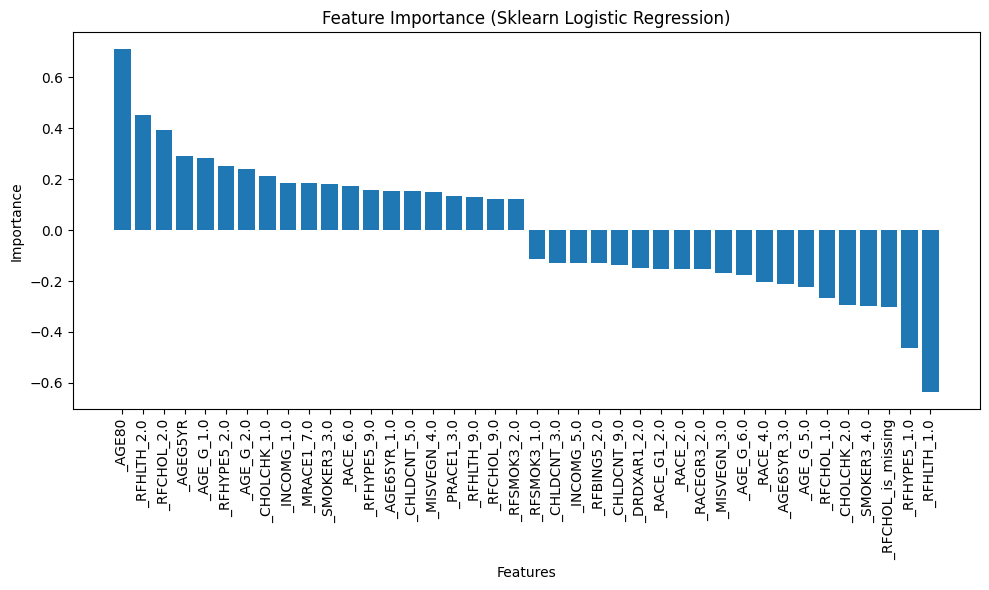

In [37]:
#create a graph showing the most important features only the first 10 and last 10 features
import matplotlib.pyplot as plt

feature_importance = (model.coef_[0])
feature_names = np.asarray(expanded_col_names)
sorted_indices = np.concatenate([np.argsort(feature_importance)[::-1][:20], np.argsort(feature_importance)[::-1][-20:]])

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_indices)), feature_importance[sorted_indices], align="center")
plt.xticks(range(len(sorted_indices)), feature_names[sorted_indices], rotation=90)
plt.title("Feature Importance (Sklearn Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [38]:
# Assume x_train, y_train, x_test, y_test are already prepared (NumPy arrays)
%autoreload 1
model = WeightedLogisticRegression(lr=0.1, n_iter=100)
model.fit(X=x_train, y=y_train)

y_pred = model.predict(X=x_test, threshold=0.5)  # Lower threshold can help with recall

#modify y_pred to be -1 and 1
y_pred = np.where(y_pred == 0, -1, 1)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy*100, "%")
print("F1 Score:", f1_score(y_test.flatten(), y_pred.flatten()))

# Confusion matrix for analysis
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Iteration 1/100
Iteration 11/100
Iteration 21/100
Iteration 31/100
Iteration 41/100
Iteration 51/100
Iteration 61/100
Iteration 71/100
Iteration 81/100
Iteration 91/100
Accuracy: 90.36067472229418 %
F1 Score: 0.16850683491062038
              precision    recall  f1-score   support

        -1.0       0.92      0.98      0.95     59787
         1.0       0.36      0.11      0.17      5840

    accuracy                           0.90     65627
   macro avg       0.64      0.55      0.56     65627
weighted avg       0.87      0.90      0.88     65627

[[58660  1127]
 [ 5199   641]]


the shape of x_train is: (262508, 165)
the shape of y_train is: (262508,)
the shape of x_test is: (65627, 165)
the shape of y_test is: (65627,)
Iter 0: train_loss=0.7291, val_loss=1.3734
Iter 10: train_loss=0.7197, val_loss=1.2956
Iter 20: train_loss=0.7139, val_loss=1.2529
Iter 30: train_loss=0.7054, val_loss=1.1784
Iter 40: train_loss=0.6984, val_loss=1.1158
Iter 50: train_loss=0.6922, val_loss=1.0575
Iter 60: train_loss=0.6877, val_loss=1.0356
Iter 70: train_loss=0.6819, val_loss=0.9921
Iter 80: train_loss=0.6777, val_loss=0.9708
Iter 90: train_loss=0.6702, val_loss=0.8860
Iter 100: train_loss=0.6651, val_loss=0.8401
Iter 110: train_loss=0.6610, val_loss=0.8096
Iter 120: train_loss=0.6578, val_loss=0.8002
Iter 130: train_loss=0.6532, val_loss=0.7490
Iter 140: train_loss=0.6482, val_loss=0.6918
Iter 150: train_loss=0.6449, val_loss=0.6887
Iter 160: train_loss=0.6418, val_loss=0.6908
Iter 170: train_loss=0.6379, val_loss=0.6571
Iter 180: train_loss=0.6346, val_loss=0.6451
Iter 190: tr

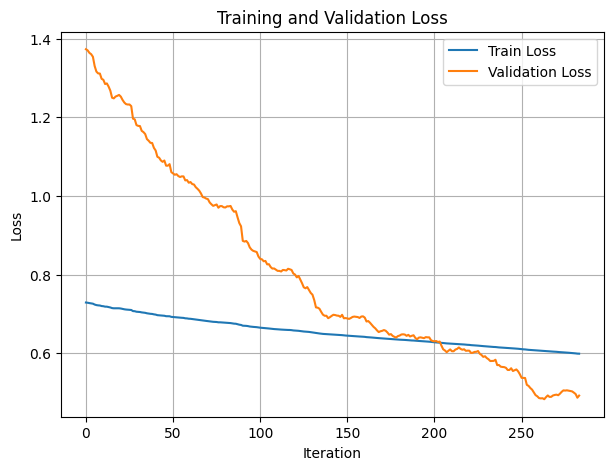

Accuracy: 71.27401831563228 %
F1 Score: 0.30985503001903647


In [94]:
%autoreload 1
model = LogisticRegression_costum(
    lr=0.001,
    max_iter=1000,
    penalty="elasticnet",
    alpha=0.001,
    class_weight={-1: 1.0, 1: 30.0},
    bias_init=0.5,
    verbose=True,
    early_stopping=True,
    method='stochastic',
    patience=20
)
print("the shape of x_train is:", x_train.shape)
print("the shape of y_train is:", y_train.shape)
print("the shape of x_test is:", x_test.shape)
print("the shape of y_test is:", y_test.shape)

model.fit(x_train, y_train, x_test, y_test)
#model.evaluate(x_test, y_test)
#use sklearn to compute f1 score
y_pred = model.predict(x_test, threshold=0.5)
accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy*100, "%")
print("F1 Score:", f1_score(y_test.flatten(), y_pred.flatten()))



In [61]:
%autoreload 1
y_pred = model.predict(x_test, threshold=0.5)
print(y_pred[:20])

[-1 -1 -1 -1  1 -1 -1  1 -1  1 -1  1 -1 -1 -1 -1 -1 -1 -1 -1]



Accuracy: 0.791

Class -1.0: precision=0.950, recall=0.814, f1=0.877, support=59787
Class 1.0: precision=0.228, recall=0.564, f1=0.325, support=5840

Macro avg:   precision=0.589, recall=0.689, f1=0.601
Weighted avg: precision=0.886, recall=0.791, f1=0.828


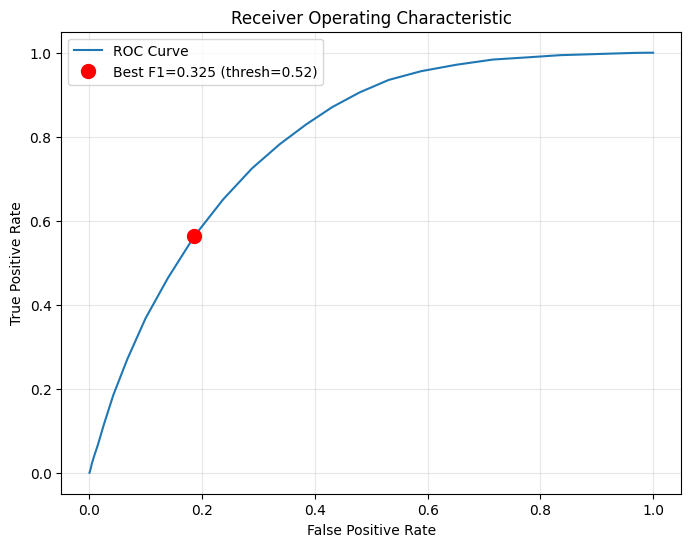

Best F1 Score: 0.3248 at threshold 0.52
TPR: 0.5637, FPR: 0.1863


In [96]:
%autoreload 1
model.evaluate(x_test, y_test, threshold=0.52)

model.roc_curve(x_test, y_test)

Grid Search

Training with lr=0.01, alpha=0.01, class_weight_1=10.0
hyper parameters: 0.01 0.01 10.0

Accuracy: 0.906

Class -1.0: precision=0.915, recall=0.989, f1=0.951, support=59787
Class 1.0: precision=0.351, recall=0.062, f1=0.106, support=5840

Macro avg:   precision=0.633, recall=0.526, f1=0.528
Weighted avg: precision=0.865, recall=0.906, f1=0.875


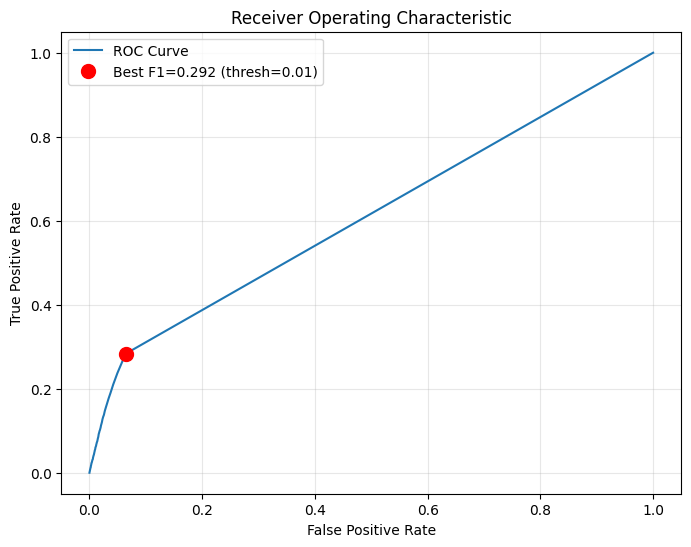

Best F1 Score: 0.2920 at threshold 0.01
TPR: 0.2832, FPR: 0.0641
Training with lr=0.01, alpha=0.01, class_weight_1=20.0
hyper parameters: 0.01 0.01 20.0

Accuracy: 0.868

Class -1.0: precision=0.928, recall=0.927, f1=0.927, support=59787
Class 1.0: precision=0.259, recall=0.262, f1=0.261, support=5840

Macro avg:   precision=0.593, recall=0.595, f1=0.594
Weighted avg: precision=0.868, recall=0.868, f1=0.868


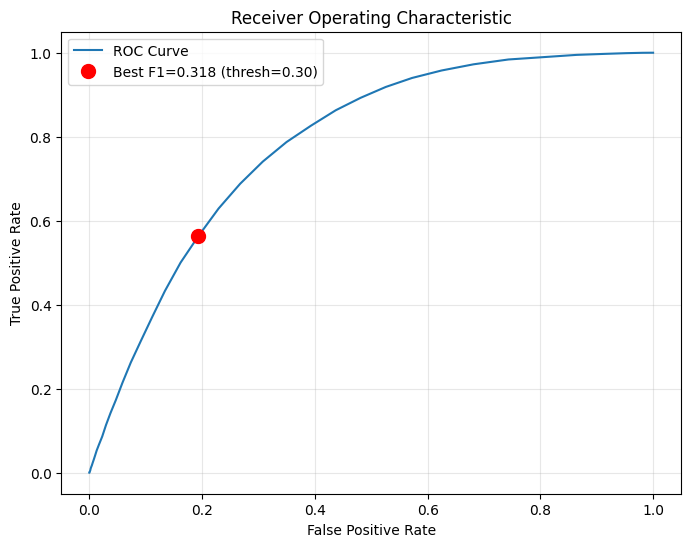

Best F1 Score: 0.3181 at threshold 0.30
TPR: 0.5635, FPR: 0.1934
Training with lr=0.01, alpha=0.01, class_weight_1=30.0
hyper parameters: 0.01 0.01 30.0

Accuracy: 0.536

Class -1.0: precision=0.985, recall=0.498, f1=0.662, support=59787
Class 1.0: precision=0.152, recall=0.921, f1=0.261, support=5840

Macro avg:   precision=0.568, recall=0.709, f1=0.461
Weighted avg: precision=0.911, recall=0.536, f1=0.626


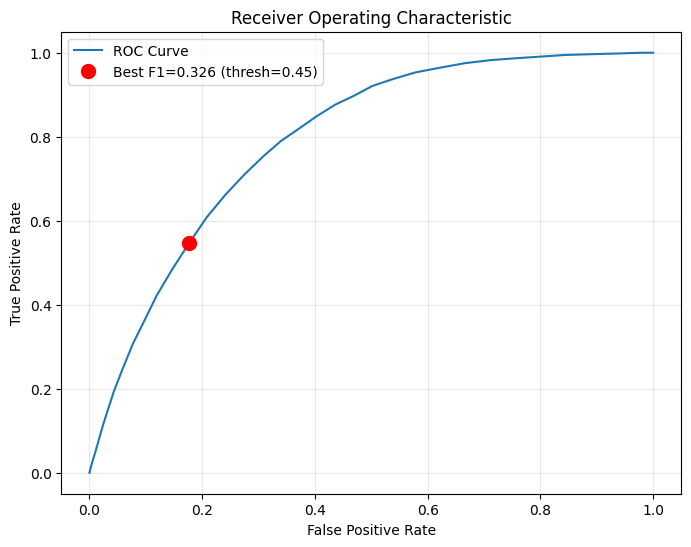

Best F1 Score: 0.3258 at threshold 0.45
TPR: 0.5473, FPR: 0.1771
Training with lr=0.01, alpha=0.001, class_weight_1=10.0
hyper parameters: 0.01 0.001 10.0

Accuracy: 0.906

Class -1.0: precision=0.916, recall=0.987, f1=0.950, support=59787
Class 1.0: precision=0.350, recall=0.070, f1=0.117, support=5840

Macro avg:   precision=0.633, recall=0.529, f1=0.533
Weighted avg: precision=0.865, recall=0.906, f1=0.876


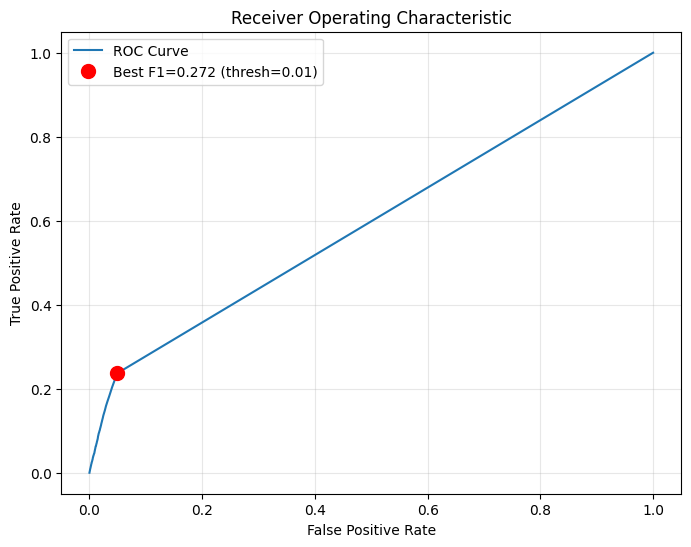

Best F1 Score: 0.2721 at threshold 0.01
TPR: 0.2366, FPR: 0.0491
Training with lr=0.01, alpha=0.001, class_weight_1=20.0
hyper parameters: 0.01 0.001 20.0

Accuracy: 0.854

Class -1.0: precision=0.934, recall=0.903, f1=0.918, support=59787
Class 1.0: precision=0.259, recall=0.347, f1=0.297, support=5840

Macro avg:   precision=0.597, recall=0.625, f1=0.608
Weighted avg: precision=0.874, recall=0.854, f1=0.863


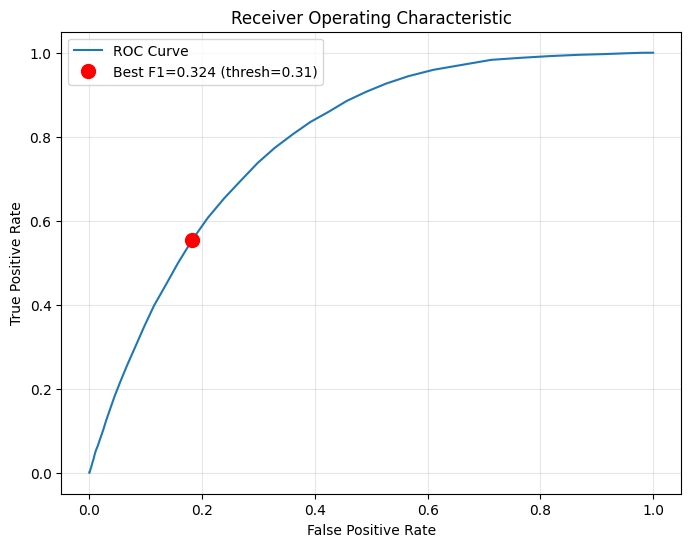

Best F1 Score: 0.3241 at threshold 0.31
TPR: 0.5538, FPR: 0.1821
Training with lr=0.01, alpha=0.001, class_weight_1=30.0
hyper parameters: 0.01 0.001 30.0

Accuracy: 0.417

Class -1.0: precision=0.991, recall=0.363, f1=0.532, support=59787
Class 1.0: precision=0.129, recall=0.967, f1=0.228, support=5840

Macro avg:   precision=0.560, recall=0.665, f1=0.380
Weighted avg: precision=0.914, recall=0.417, f1=0.504


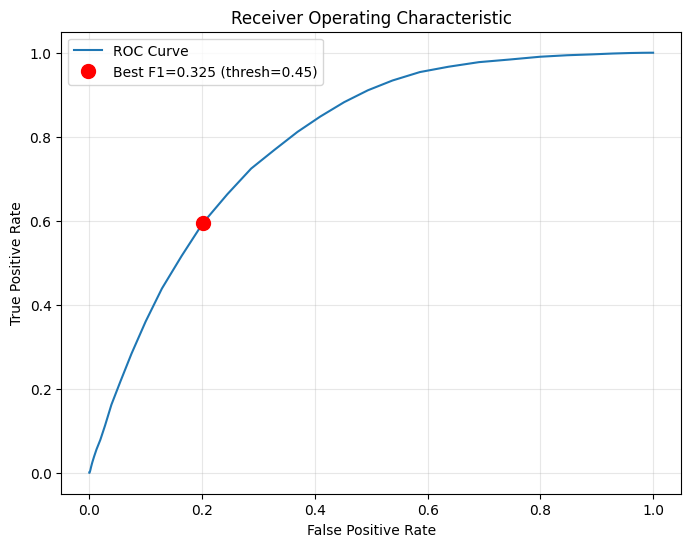

Best F1 Score: 0.3253 at threshold 0.45
TPR: 0.5943, FPR: 0.2012
Training with lr=0.001, alpha=0.01, class_weight_1=10.0
hyper parameters: 0.001 0.01 10.0

Accuracy: 0.910

Class -1.0: precision=0.911, recall=0.999, f1=0.953, support=59787
Class 1.0: precision=0.256, recall=0.004, f1=0.007, support=5840

Macro avg:   precision=0.584, recall=0.501, f1=0.480
Weighted avg: precision=0.853, recall=0.910, f1=0.869


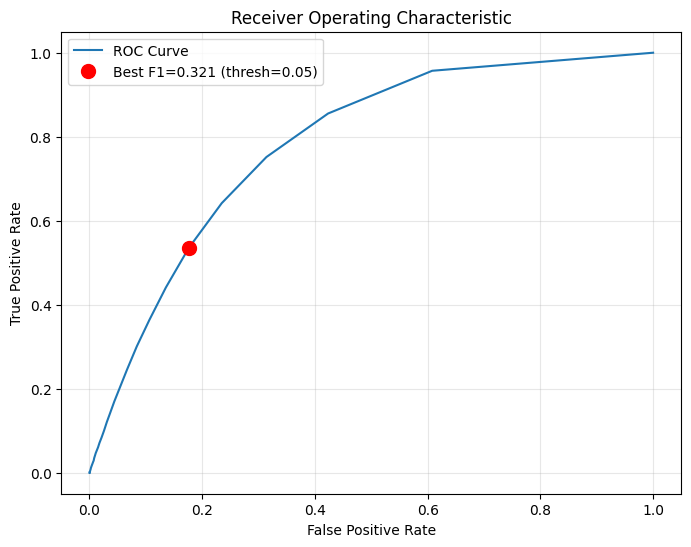

Best F1 Score: 0.3205 at threshold 0.05
TPR: 0.5353, FPR: 0.1763
Training with lr=0.001, alpha=0.01, class_weight_1=20.0
hyper parameters: 0.001 0.01 20.0

Accuracy: 0.718

Class -1.0: precision=0.962, recall=0.719, f1=0.823, support=59787
Class 1.0: precision=0.197, recall=0.705, f1=0.308, support=5840

Macro avg:   precision=0.579, recall=0.712, f1=0.565
Weighted avg: precision=0.894, recall=0.718, f1=0.777


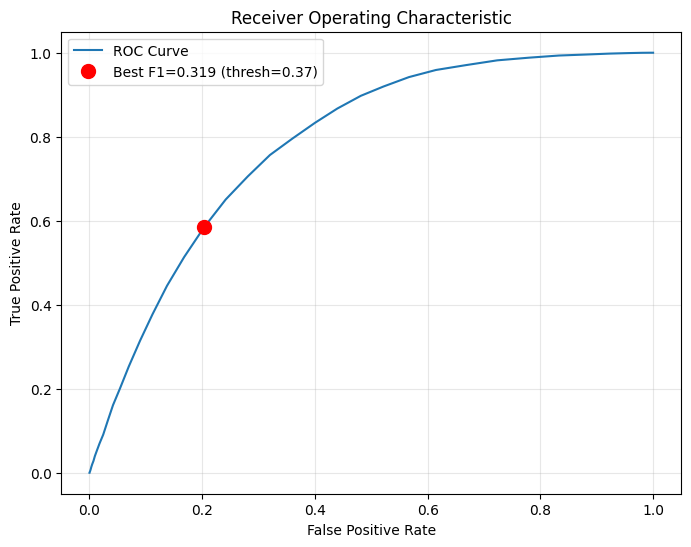

Best F1 Score: 0.3188 at threshold 0.37
TPR: 0.5846, FPR: 0.2035
Training with lr=0.001, alpha=0.01, class_weight_1=30.0
hyper parameters: 0.001 0.01 30.0

Accuracy: 0.490

Class -1.0: precision=0.989, recall=0.446, f1=0.614, support=59787
Class 1.0: precision=0.143, recall=0.947, f1=0.249, support=5840

Macro avg:   precision=0.566, recall=0.697, f1=0.432
Weighted avg: precision=0.913, recall=0.490, f1=0.582


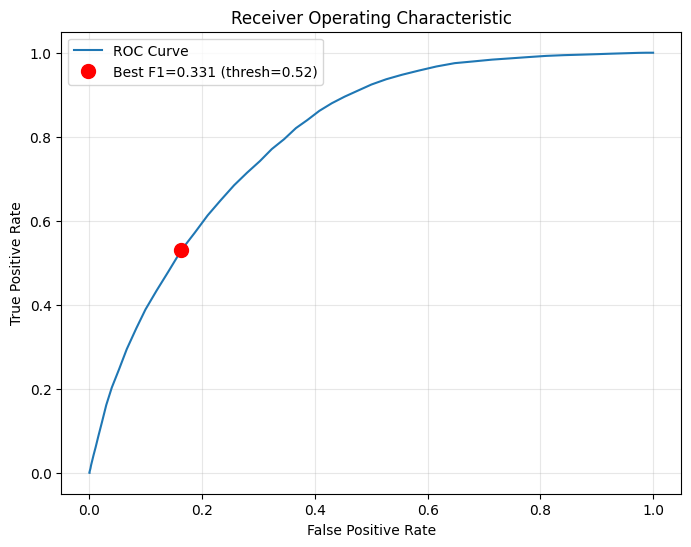

Best F1 Score: 0.3314 at threshold 0.52
TPR: 0.5303, FPR: 0.1632
Training with lr=0.001, alpha=0.001, class_weight_1=10.0
hyper parameters: 0.001 0.001 10.0

Accuracy: 0.910

Class -1.0: precision=0.911, recall=0.999, f1=0.953, support=59787
Class 1.0: precision=0.267, recall=0.004, f1=0.008, support=5840

Macro avg:   precision=0.589, recall=0.502, f1=0.481
Weighted avg: precision=0.854, recall=0.910, f1=0.869


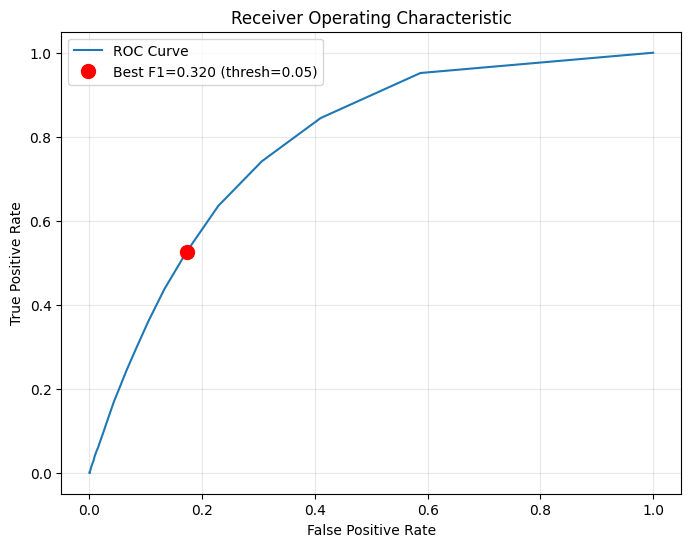

Best F1 Score: 0.3198 at threshold 0.05
TPR: 0.5265, FPR: 0.1726
Training with lr=0.001, alpha=0.001, class_weight_1=20.0
hyper parameters: 0.001 0.001 20.0

Accuracy: 0.689

Class -1.0: precision=0.965, recall=0.683, f1=0.800, support=59787
Class 1.0: precision=0.187, recall=0.745, f1=0.299, support=5840

Macro avg:   precision=0.576, recall=0.714, f1=0.549
Weighted avg: precision=0.896, recall=0.689, f1=0.756


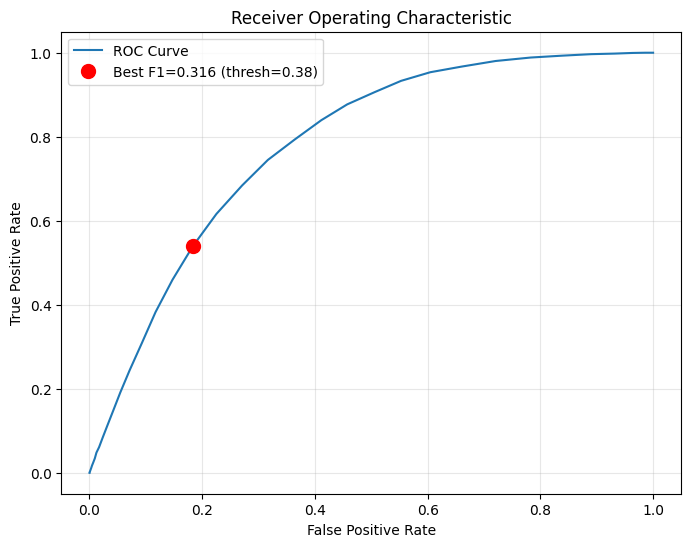

Best F1 Score: 0.3157 at threshold 0.38
TPR: 0.5397, FPR: 0.1836
Training with lr=0.001, alpha=0.001, class_weight_1=30.0
hyper parameters: 0.001 0.001 30.0

Accuracy: 0.098

Class -1.0: precision=1.000, recall=0.010, f1=0.020, support=59787
Class 1.0: precision=0.090, recall=1.000, f1=0.165, support=5840

Macro avg:   precision=0.545, recall=0.505, f1=0.092
Weighted avg: precision=0.919, recall=0.098, f1=0.032


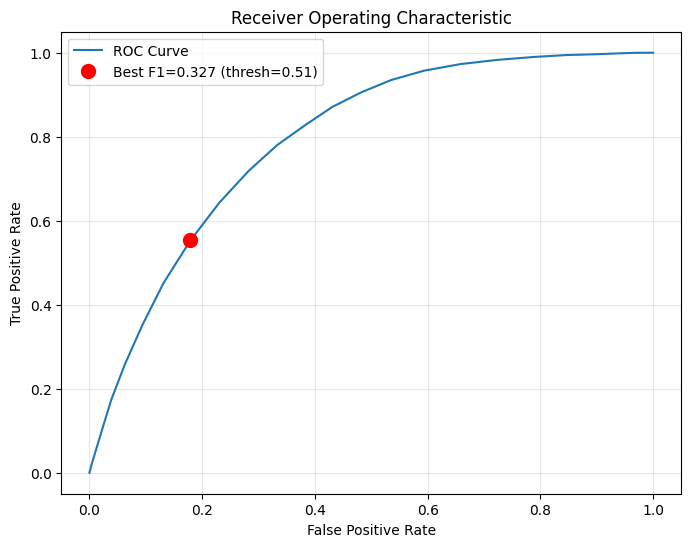

Best F1 Score: 0.3265 at threshold 0.51
TPR: 0.5531, FPR: 0.1792


In [ ]:
#import libraries
import numpy as np
from helper import *#import helper functions
import list as lt
%load_ext autoreload
%aimport helper, list  
%autoreload 1

#grid search for hyperparameters, returns at the end the best model found
best_f1_overall = 0
best_thresh_overall = 0
best_col_list = None
best_lr = 0
best_alpha = 0
best_class_weight_1 = 0
for col_list in [lt.col_list, lt.col_list_2, lt.col_list_3]:
    header = load_header('../data/dataset/x_test.csv')
    x_train_expanded, expanded_col_names = expand_dataset_col(col_list, '../data/dataset/x_train.csv')
    x_train_full = x_train_expanded#load_data_column('x_train_expanded.csv', column_list=None)
    y_train_full = load_data_col('../data/dataset/y_train.csv', cols=(1))
    x_train,y_train,x_test,y_test = split_data_train_test_80(x_train_full, y_train_full, seed=1)
    for  lr in [0.1, 0.01, 0.001]:
        for alpha in [0.1, 0.01, 0.001]:
            for class_weight_1 in [10.0, 20.0, 30.0]:
                print(f"Training with lr={lr}, alpha={alpha}, class_weight_1={class_weight_1}")
                model = LogisticRegression_costum(
                    lr=lr,
                    max_iter=1000,
                    penalty="elasticnet",
                    alpha=alpha,
                    class_weight={-1: 1.0, 1: class_weight_1},
                    bias_init=0.5,
                    verbose=False,
                    early_stopping=True,
                    method='stochastic',
                    patience=20
                )
                model.fit(x_train, y_train, x_test, y_test)
                y_pred = model.predict(x_test, threshold=0.5)
                temp_f1, temp_thresh = model.roc_curve(x_test, y_test)
                if temp_f1 > best_f1_overall:
                    best_f1_overall = temp_f1
                    best_thresh_overall = temp_thresh
                    best_col_list = col_list
                    best_lr = lr
                    best_alpha = alpha
                    best_class_weight_1 = class_weight_1
                    print(f"New Best F1 Score: {best_f1_overall:.4f} at threshold {best_thresh_overall:.2f}")


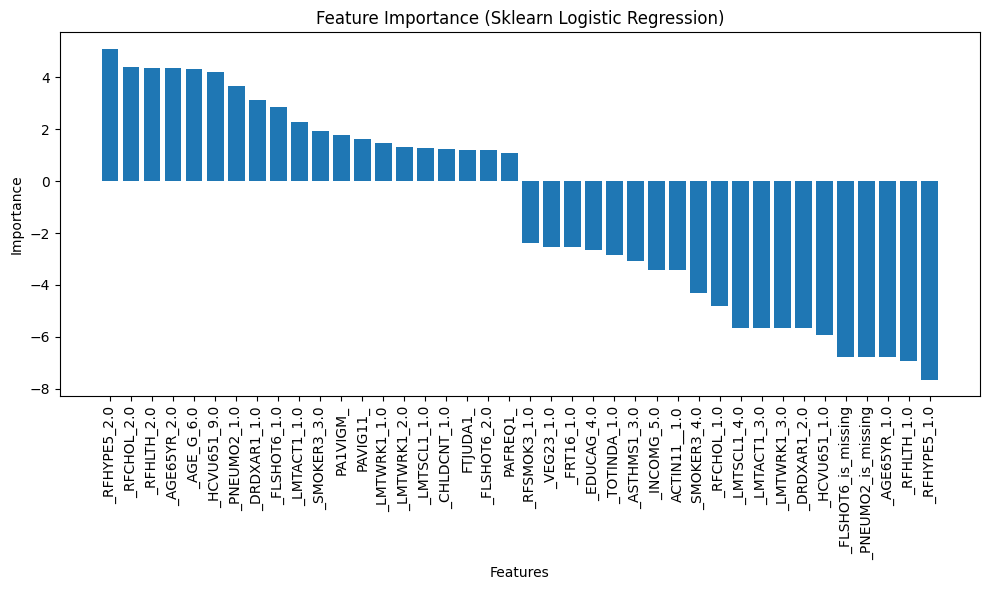

In [11]:
feature_importance = (model.weights_[1:])  # Exclude intercept
feature_names = np.asarray(expanded_col_names)
sorted_indices = np.concatenate([np.argsort(feature_importance)[::-1][:20], np.argsort(feature_importance)[::-1][-20:]])

plt.figure(figsize=(10, 6))
plt.bar(range(len(sorted_indices)), feature_importance[sorted_indices], align="center")
plt.xticks(range(len(sorted_indices)), feature_names[sorted_indices], rotation=90)
plt.title("Feature Importance (Sklearn Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [22]:
y_test_pred_sklearn = np.where(y_pred_sklearn == 0, -1, 1)
print("Predictions from our model after modification:", y_pred_sklearn.flatten()[:100])
#calulate accuracy and f1 score for sklearn model
accuracy_sklearn = np.mean(y_pred_sklearn == y_test.flatten())
print(f"Sklearn Logistic Regression Accuracy: {accuracy_sklearn * 100:.2f}%")
#caluculate f1
f1_sklearn = f1_score(y_test.flatten(), y_pred_sklearn)
print(f"Sklearn F1 Score: {f1_sklearn:.4f}")

Predictions from our model after modification: [-1. -1. -1. -1.  1. -1.  1.  1. -1.  1.  1.  1. -1.  1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1.  1. -1.  1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1. -1.
 -1. -1. -1. -1. -1. -1. -1. -1.  1. -1. -1.  1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1.  1. -1. -1. -1.  1.  1. -1. -1. -1. -1. -1. -1. -1.  1. -1.
 -1. -1.  1. -1. -1. -1. -1.  1. -1.  1.]
Sklearn Logistic Regression Accuracy: 83.47%
Sklearn F1 Score: 0.3732


In [99]:
header = load_header('../data/dataset/x_train.csv')
print(header)
header_test = load_header('../data/dataset/x_test.csv')
print(header_test)
#check differences between header and header_test
for col in header:
    if col not in header_test:
        print(f"Column '{col}' is in train but not in test.")  

['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3', 'LADULT', 'NUMADULT', 'NUMMEN', 'NUMWOMEN', 'CTELNUM1', 'CELLFON2', 'CADULT', 'PVTRESD2', 'CCLGHOUS', 'CSTATE', 'LANDLINE', 'HHADULT', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'BPHIGH4', 'BPMEDS', 'BLOODCHO', 'CHOLCHK', 'TOLDHI2', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'DIABAGE2', 'SEX', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL2', 'NUMPHON2', 'CPDEMO1', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME2', 'INTERNET', 'WEIGHT2', 'HEIGHT3', 'PREGNANT', 'QLACTLM2', 'USEEQUIP', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'SMOKE100', 'SMOKDAY2', 'STOPSMK2', 'LASTSMK2', 'USENOW3', 'ALCDAY5', 'AVEDRNK2', 'DRNK3GE5', 'MAXDRNKS', 'FRUITJU1', 'FRUIT1', 'FVBEANS', 'FVGREEN', 'FVORANG', 'VEGETAB1', 'EXERANY2', 'EXR

In [101]:
#Create a csv submission file with the predictions on the test set

#x_test_sub = load_data_col('../data/dataset/x_test.csv', cols=col_index)
x_test_sub_exp, header_expanded_test = expand_dataset_col(col_list, '../data/dataset/x_test.csv' )
print(" header:", header_expanded_test)
print("start filling missing columns")
x_test_sub_exp_better = fill_missing_column(expanded_col_names, header_expanded_test, x_test_sub_exp)
print("end filling missing columns")

print("normal expansion"+str(x_test_sub_exp.shape))
print("better expansion"+str(x_test_sub_exp_better.shape))
y_pred_probabilities = model.predict_proba(X=x_test_sub_exp_better)
print("Predicted probabilities from our model:", y_pred_probabilities.flatten()[:100])
y_pred = model.predict(X=x_test_sub_exp_better, threshold=0.1)
print("Predictions from our model:", y_pred.flatten()[:100])

#calculate accuracy and f1 score for sklearn model on test submission set
#predict using the weights generated by our model
# prepare ids for submission: try loading an ID column, otherwise use 1..N
try:
    ids = load_data_col('../data/dataset/x_test.csv', cols=(0,), has_header=True).astype(int)
except Exception:
    ids = np.arange(1, x_test_sub_exp_better.shape[0] + 1)
create_csv_submission(ids, y_pred, "submission.csv")


Original col_list: ['_RFHLTH', '_HCVU651', '_RFHYPE5', '_CHOLCHK', '_RFCHOL', '_ASTHMS1', '_DRDXAR1', '_HISPANC', '_RACE', '_AGE65YR', '_AGE_G', '_HTM4', '_WTKG3', '_BMI5CAT', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_SMOKER3', '_RFSMOK3', '_DRNKANY5', '_RFBING5', '_RFDRHV5', 'FTJUDA1', 'FRUTDA1', 'BEANDAY', 'GRENDAY', 'ORNGDAY', 'VEGEDA1', '_MISFRTN', '_MISVEGN', '_FRTRESP', '_VEGRESP', '_FRUTSUM', '_VEGESUM', '_FRTLT1', '_VEGLT1', '_FRT16', '_VEG23', '_FRUITEX', '_VEGETEX', '_TOTINDA', 'METVL11', 'METVL21', 'MAXVO2', 'FC60', 'ACTIN11', 'ACTIN21', 'PADUR1', 'PADUR2', 'PAFREQ1', 'PAFREQ2', 'MINAC11', 'MINAC21', 'STRFREQ', 'PAMISS1', 'PAMIN11', 'PAMIN21', 'PA1MIN', 'PAVIG11', 'PAVIG21', 'PA1VIGM', 'PACAT1', 'PAINDX1', 'PASTRNG', 'PAREC1', 'PASTAE1', 'LMTACT1', 'LMTWRK1', 'LMTSCL1', 'RFSEAT2', 'RFSEAT3', 'FLSHOT6', 'PNEUMO2', 'AIDTST3']
Header: ['Id', '_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENUM', 'PVTRESD1', 'COLGHOUS', 'STATERES', 'CELLFON3',

In [ ]:
x_test_sub_exp_better.shape